In [1]:
import time
from edu1sces.model import HeisenbergModel
from edu1sces.solver import solve, SolverParameters
import matplotlib.pyplot as plt

In [2]:
N = 6
total_sz = 0
model = HeisenbergModel(
    spins={i: 0.5 for i in range(N)},
    exchange_xy={(i, (i + 1)): 1.0 for i in range(N - 1)},
    exchange_z={(i, (i + 1)): 1.0 for i in range(N - 1)},
)
params = SolverParameters(output_log=True, num_threads=6)
result = solve(model, total_sz=total_sz, params=params)
print(f"Energy: {result.energy}")

Building basis...
Done in 0.0s (6 threads)
Building Hamiltonian...
Done in 0.0s (6 threads)
Diagonalizing Hamiltonian...
Done in 0.0s (6 threads)                      
Improving eigenvector...
Done in 0.0s (6 threads)                      
Energy: -2.4935771338879276


In [3]:
Sz_cfs = []
time_start = time.perf_counter()
for i in range(1, N):
    Sz_0 = model.make_local_op_sz(0)
    Sz_i = model.make_local_op_sz(i)
    Sz_cfs.append(result.correlation_function(Sz_0, 0, Sz_i, i))
time_end = time.perf_counter()
print(f"Elapsed time: {time_end - time_start} sec")

Elapsed time: 0.0019275830054539256 sec


In [4]:
Sx_cfs = []
time_start = time.perf_counter()
for i in range(1, N):
    Sx_0 = model.make_local_op_sx(0)
    Sx_i = model.make_local_op_sx(i)
    Sx_cfs.append(result.correlation_function(Sx_0, 0, Sx_i, i))
time_end = time.perf_counter()
print(f"Elapsed time: {time_end - time_start} sec")

Elapsed time: 0.001084750001609791 sec


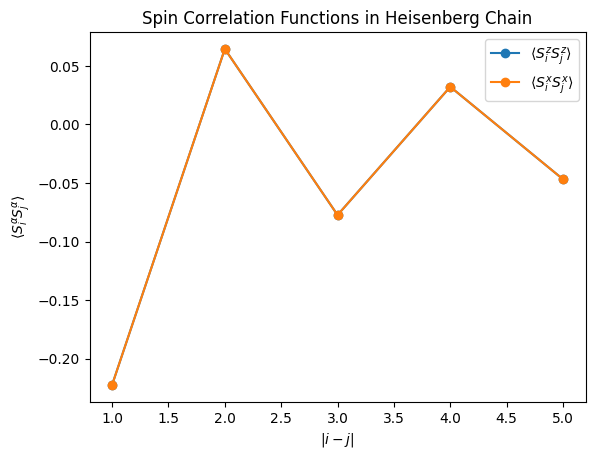

In [5]:
plt.plot(range(1, N), Sz_cfs, marker="o", label=r"$\langle S_i^z S_j^z \rangle$")
plt.plot(range(1, N), Sx_cfs, marker="o", label=r"$\langle S_i^x S_j^x \rangle$")
plt.xlabel(r"$|i-j|$")
plt.ylabel(r"$\langle S_i^\alpha S_j^\alpha \rangle$")
plt.title("Spin Correlation Functions in Heisenberg Chain")
plt.legend()

In [6]:
Sz_cfs

[-0.2224872074751867,
 0.06450935603477927,
 -0.07737136916489437,
 0.03216907316275276,
 -0.04681985255745106]